# Jupyter Notebook 2. Эксперименты с моделями и валидация

**Стажёр:** [Парцей Петр]

На входе — готовый датасет, подготовленный ранее и разделённый на тренировочную и тестовую выборки.

На выходе — финальная модель, карточка модели и SHAP-анализ.

## 1. Подключение библиотек

In [ ]:
!pip install optuna shap boto3 -q

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import StratifiedKFold, cross_validate

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
import catboost as cb
import optuna
import shap
import io
import os
import boto3
import botocore
from dotenv import load_dotenv
import pickle


In [2]:
RANDOM_STATE = 42

## 2. Загрузка данных

Загрузите `train` и `test` выборки из тетради 1. Проверьте размеры выборок и баланс классов.

In [36]:
# Загрузка
df = joblib.load('ready_dataset.joblib')

# Быстрое восстановление выборок без повторного разбиения
train_part = df[df['split'] == 'train'].drop(columns=['split'])
test_part = df[df['split'] == 'test'].drop(columns=['split'])

X_train = train_part.drop(columns=['is_high_demand'])
y_train = train_part['is_high_demand']

X_test = test_part.drop(columns=['is_high_demand'])
y_test = test_part['is_high_demand']

Проверяем размер выборок:

In [37]:
print(f'Размер train: {len(y_train):,} объектов')
print(f'Размер test:  {len(y_test):,} объектов')
print(f'Всего:        {len(y_train) + len(y_test):,} объектов')

Размер train: 121,676 объектов
Размер test:  30,420 объектов
Всего:        152,096 объектов


Проверяем баланс классов по выборкам:

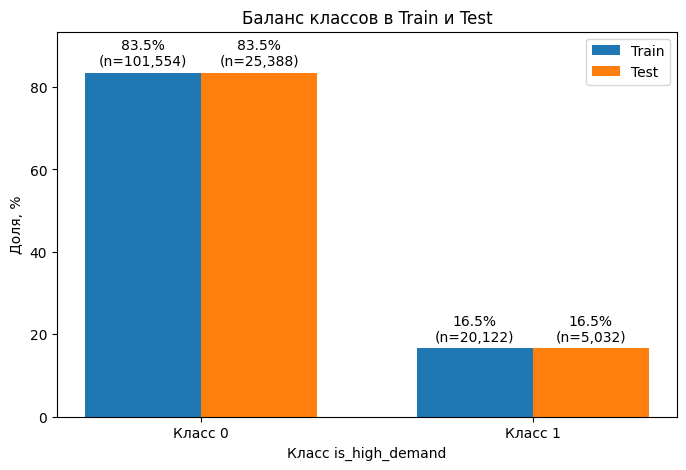

In [38]:
# Доли классов
train_percent = y_train.value_counts(normalize=True).sort_index() * 100
test_percent = y_test.value_counts(normalize=True).sort_index() * 100

# Позиции
x = [0, 1]
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars_train = ax.bar([i - width / 2 for i in x], train_percent.values, width, label='Train')

bars_test = ax.bar([i + width / 2 for i in x], test_percent.values, width, label='Test')

# Подписи процентов
for bars, counts, total in [
    (bars_train, train_percent, len(y_train)),
    (bars_test, test_percent, len(y_test))
]:
    for bar, percent in zip(bars, counts.values):
        height = bar.get_height()
        # Количество объектов данного класса
        class_count = round(percent / 100 * total)
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f'{percent:.1f}%\n(n={class_count:,})',
            ha='center',
            va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(['Класс 0', 'Класс 1'])
ax.set_ylabel('Доля, %')
ax.set_xlabel('Класс is_high_demand')
ax.set_title('Баланс классов в Train и Test')
ax.legend()

plt.ylim(0, max(train_percent.max(), test_percent.max()) + 10)
plt.show()

**Баланс классов в `train` и `test`:**

В обеих выборках наблюдается идентичный баланс: преобладающий «Класс 0» составляет 83,5%, а «Класс 1» занимает 16,5%.

## 3. Baseline

Постройте простую базовую модель: она задаст точку отсчёта для всех последующих экспериментов. Если сложная модель едва бьёт baseline — стоит задуматься.

Зафиксируйте метрики базовой модели в таблице экспериментов далее в этом уроке.

В качестве базовой модели используем Логистическую регрессию. Для работы с текстовыми подходит класс TfidfVectorizer. Английские стоп-слова в нём есть, загружаем дополнительно русские:

In [6]:
# Загружаем список стоп-слов 
nltk.download('stopwords')
russian_stop_words = stopwords.words('russian')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Создаём список признаков и пайплан для их предобработки:

In [39]:
cat_lr_features = ['property_type', 'neighbourhood_cleansed']

num_features = ['host_listings_count', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms',
    'beds', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
    'minimum_nights_avg_ntm', 'amenities_count', 'host_trust_score', 'guests_per_bedroom']

binary_features = ['host_has_profile_pic', 'host_identity_verified', 'instant_bookable',
     'has_email_verification', 'has_work_email_verification', 'is_shared_bathroom']

#  Бинарные признаки наличия удобст. Названия начинаются с 'amenity_'
amenity_features = [col for col in df.columns if col.startswith('amenity_')]
#  Собираем предобработчик
preprocessor = ColumnTransformer(transformers=[
    ('target', TargetEncoder(smooth='auto'), cat_lr_features),
    ('binary', 'passthrough', binary_features),
    ('amenity', 'passthrough', amenity_features),
    ('num', StandardScaler(), num_features),
    ('tfidf_name', TfidfVectorizer(stop_words=russian_stop_words, max_features=1000, ngram_range=(1, 2), 
                min_df=5, max_df=0.8), 'name')], remainder='drop')

#  Финальный пайплайн
base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))])

Проверяем работу базовой модели с кроссвалидацией:

In [40]:
# Определяем словарь нужных метрик
scoring_metrics = {"precision": "precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "recall": "recall"}

# Настраиваем стратифицированное разбиение с перемешиванием
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Запускаем кросс-валидацию, передав stratified_cv в параметр cv
cv_results = cross_validate(
    base_pipeline,
    X_train,
    y_train,
    cv=stratified_cv,  
    scoring=scoring_metrics,
    n_jobs=-1)

# Выводим средние результаты по всем фолдам
print(f"--- Результаты кросс-валидации (Mean) ---")
print(f"Главная метрика -> Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Recall:                         {cv_results['test_recall'].mean():.4f}")
print(f"F1-Score:                       {cv_results['test_f1'].mean():.4f}")
print(f"ROC-AUC:                        {cv_results['test_roc_auc'].mean():.4f}")


--- Результаты кросс-валидации (Mean) ---
Главная метрика -> Precision: 0.5412
Recall:                         0.1360
F1-Score:                       0.2174
ROC-AUC:                        0.7775


**Метрики baseline и выводы:**

Модель демонстрирует умеренную точность по главной метрике (Precision = 0.5412), правильно классифицируя лишь половину объектов, отнесенных к целевому классу. При этом наблюдается критически низкий охват (Recall = 0.1360), из-за чего модель пропускает подавляющее большинство реальных объектов «Класса 1» и выдает слабый итоговый баланс F1-Score (0.2174). Высокое значение ROC-AUC (0.7775) указывает на хороший разделительный потенциал вероятностей, который можно реализовать в пользу Precision путем ручной настройки порога классификации.

## 4. Эксперименты с моделями

Попробуйте обучить разные модели и наборы признаков. Каждый эксперимент фиксируйте в таблице.

> Если класс несбалансирован, то учитывайте это при выборе метрик и настройке моделей. Обоснуйте выбор.

> Тестовая выборка используется **только один раз** — для финальной оценки лучшей модели. Не используйте её во время экспериментов.

In [41]:
# Объединяем текстовые колонки
text_features = ["name"]

# Объединяем категориальные, бинарные и amenity признаки в один список cat_features
cat_features = (["property_type", "neighbourhood_cleansed", "room_type", "has_phone_verification"]
    + binary_features
    + amenity_features)

# Собираем полный список колонок, которые пойдут в модель (включая числовые)
all_features = num_features + cat_features + text_features

X_data = X_train[all_features].copy()

# Приводим все категории и тексты к строковому типу (требование CatBoost)
for col in text_features + cat_features:
    X_data[col] = X_data[col].astype(str)

# Выделяем валидационную выборку (20%)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_data, y_train, test_size=0.2, stratify=y_train, random_state=42)

# Создаем специальные объекты Pool для CatBoost (это ускоряет работу)
train_pool = Pool(data=X_tr,
    label=y_tr,
    cat_features=cat_features,
    text_features=text_features)
val_pool = Pool(data=X_val,
    label=y_val,
    cat_features=cat_features,
    text_features=text_features)

# Инициализируем и обучаем CatBoostClassifier
model = CatBoostClassifier(random_seed=42, verbose=False)

model.fit(train_pool, eval_set=val_pool)

# Получаем предсказания и считаем метрики
y_pred = model.predict(val_pool)
y_proba = model.predict_proba(val_pool)[:, 1]

print("\n--- Результаты CatBoost 'из коробки' ---")
print(f"Главная метрика -> Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall:                         {recall_score(y_val, y_pred):.4f}")
print(f"F1-Score:                       {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC:                        {roc_auc_score(y_val, y_proba):.4f}")



--- Результаты CatBoost 'из коробки' ---
Главная метрика -> Precision: 0.6145
Recall:                         0.2147
F1-Score:                       0.3182
ROC-AUC:                        0.8153


Переход на CatBoost дал  прирост по всем показателям. Главная метрика Precision выросла до 0.6145, а Recall увеличился по сравнению с логистической регрессией. Высокое значение ROC-AUC (0.8153) подтверждает, что нелинейные алгоритмы бустинга гораздо эффективнее связывают между собой районы, типы недвижимости и текстовые эмбеддинги. Модель «из коробки» показала отличный потенциал для работы с дисбалансом.

### 4.1 Таблица экспериментов

Заполняйте таблицу по мере обучения моделей:

Precision:  P0.6076
Recall:                         0.2489
F1-Score:                       0.3532
ROC-AUC:                        0.8150

| № | Алгоритм | Признаки | Дисбаланс | ROC-AUC | F1 | Precision | Recall | Примечание |
|---|----------|----------|-----------|---------|----|-----------|---------|-----------|
| 1 | Baseline | Все, кроме city, room_type и has_phone_verification | 83.5\16.5 |0.7775 | 0.2174|0.5412 | 0.1360| LogisticRegression|
| 2 |CatBoost 'из коробки' |Все | 83.5\16.5| 0.8153| 0.3182|0.6145 |0.2147 | |
| 3 |LogisticRegression с балансировкой классов | Все, кроме city, room_type и has_phone_verification|class_weight ='balanced' |0.7772 |0.4433 |0.3209 |0.7165 | |
| 4 |LogisticRegression с регуляризацией | Все, кроме city, room_type и has_phone_verification|83.5\16.5 |0.7641 |0.1075 |0.5325 |0.0598 |C=0.01, penalty='l1', solver='saga' |
| 5 | CatBoostClassifier с балансировкой классов|Все | scale_pos_weight =2.5|0.8163 | 0.4870|0.4670 |0.5088 | |
| 6 | CatBoostClassifier с регуляризацией|Все |83.5\16.5 | 0.8091|0.2821| 0.6342|0.1814 | iterations=2000, learning_rate=0.02, depth=5, l2_leaf_reg=10|
| 7 |CatBoostClassifier с регуляризацией, более мягкой балансировкой и продвинутой обработкой текста|Все и дополнительная обработка текстовых | scale_pos_weight =1.5|0.8137 |0.4169 | 0.5410|0.3391 |text_processing =text_processing_config |
| 8 |CatBoost 'из коробки' |Все и дополнительная обработка текстовых |83.5\16.5 | 0.8150 | 0.3532| 0.6076| 0.2489|text_processing =text_processing_config |

### 4.2 Эксперименты

Так как в целевой переменной наблюдается сильный дисбаланс 83.5\16.5 добавим в линейную модель параметр балансировки class_weight='balanced'.

In [42]:
# Эксперимент 1
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))]) 

# Запускаем кросс-валидацию
cv_results = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=stratified_cv,  # ИСУПРАВЛЕНО: теперь разбиение строго контролируется
    scoring=scoring_metrics,
    n_jobs=-1)

#  Выводим средние результаты по всем фолдам
print(f"--- Результаты кросс-валидации с балансом классов (Mean) ---")
print(f"Главная метрика -> Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Recall:                         {cv_results['test_recall'].mean():.4f}")
print(f"F1-Score:                       {cv_results['test_f1'].mean():.4f}")
print(f"ROC-AUC:                        {cv_results['test_roc_auc'].mean():.4f}")


--- Результаты кросс-валидации с балансом классов (Mean) ---
Главная метрика -> Precision: 0.3209
Recall:                         0.7165
F1-Score:                       0.4433
ROC-AUC:                        0.7772


Использование параметра class_weight='balanced' кардинально изменило поведение модели, заставив её отдавать приоритет полноте в ущерб точности предсказаний. В результате Recall успешно увеличился до 0.7165, однако главная метрика Precision критически упала до 0.3209 из-за резкого роста ложноположительных срабатываний. Рост итогового F1-Score (0.4433) и стабильный ROC-AUC (0.7772) подтверждают общую адекватность модели, но для достижения высоких бизнес-метрик данный режим балансировки неприемлем из-за чрезмерного снижения точности.

В линейную модель добавляем регуляризацию, чтобы избежать переобучения. Используем penalty='l1', так модель обнулит веса признаков, которые мало влияют на результат. 

In [43]:
# Эксперимент 2
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(C=0.01, penalty='l1', solver='saga', random_state=42, max_iter=1000))])

# Запускаем кросс-валидацию, передав stratified_cv в параметр cv
cv_results = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=stratified_cv,
    scoring=scoring_metrics,
    n_jobs=-1)

#  Выводим средние результаты по всем фолдам
print(f"--- Результаты кросс-валидации с регуляризацией (Mean) ---")
print(f"Главная метрика -> Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Recall:                         {cv_results['test_recall'].mean():.4f}")
print(f"F1-Score:                       {cv_results['test_f1'].mean():.4f}")
print(f"ROC-AUC:                        {cv_results['test_roc_auc'].mean():.4f}")

--- Результаты кросс-валидации с регуляризацией (Mean) ---
Главная метрика -> Precision: 0.5325
Recall:                         0.0598
F1-Score:                       0.1075
ROC-AUC:                        0.7641


Введение L1-регуляризации с жестким коэффициентом C=0.01 заставило модель радикально занулить слабые признаки, повысив точность (Precision = 0.5325) за счет снижения шума в текстовых и категориальных эмбеддингах. Однако из-за чрезмерно консервативного отбора признаков пострадал охват (Recall = 0.0598), так как алгоритм теперь предсказывает целевой класс только при абсолютной уверенности. Метрика ROC-AUC осталась стабильно высокой (0.7641), что подтверждает правильный вектор настройки и открывает возможность для плавного ослабления регуляризации (например, до C=0.1) с целью вернуть баланс полноты без потери точности.

Обучаем модель с балансом классов 2.5. В датасете дисбаланс составляет 83.5\16.5, это примерно пять к одному. Но при scale_pos_weight ≈ 5 модель станет слишком чувствительной к миноритарному классу и начнёт выдавать много ложных срабатываний. Значение 2.5 даёт более умеренный сдвиг порога, модель всё ещё учитывает дисбаланс, но не жертвует точностью.

In [44]:
# Эксперимент 3
# Инициализируем и обучаем CatBoostClassifier
model = CatBoostClassifier(random_seed=42, verbose=False, scale_pos_weight=2.5)

model.fit(train_pool, eval_set=val_pool)

# Получаем предсказания и считаем метрики
y_pred = model.predict(val_pool)
y_proba = model.predict_proba(val_pool)[:, 1]

print("\n--- Результаты CatBoost с настройкой баланса ---")
print(f"Главная метрика -> Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall:                         {recall_score(y_val, y_pred):.4f}")
print(f"F1-Score:                       {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC:                        {roc_auc_score(y_val, y_proba):.4f}")


--- Результаты CatBoost с настройкой баланса ---
Главная метрика -> Precision: 0.4670
Recall:                         0.5088
F1-Score:                       0.4870
ROC-AUC:                        0.8163


Установка параметра scale_pos_weight=2.5 позволила найти компромисс между точностью и полнотой, сбалансировав метрики Precision (0.4670) и Recall (0.5088) практически на одном уровне. Хотя точность снизилась по сравнению с базовой моделью, охват целевого класса вырос более чем в два раза, что привело к лучшему значению F1-Score (0.4870). Стабильно высокий показатель ROC-AUC (0.8163) подтверждает, что бустинг сохраняет сильную разделительную способность.

Проверяем модель с другими параметрами для борьбы с дисбалансом и переобучением: сниженный learning_rate (0.02) и увеличенное число итераций (2000) обеспечивают стабильную и точную сходимость; уменьшенная глубина деревьев (depth=5) ограничивает сложность правил и повышает обобщение; увеличенная L2‑регуляризация (l2_leaf_reg=10) подавляет влияние шумных признаков. 

In [45]:
# Эксперимент 4
# Инициализируем модель с новыми параметрами 
model = CatBoostClassifier(
    iterations=2000,  # Увеличили (было 1000), чтобы модель успела дообучиться при малом шаге
    learning_rate=0.02,  # Уменьшили шаг (было 0.05) для более точной настройки весов
    depth=5,  # Снизили до 5 (было 6) для построения более простых и обобщенных правил
    l2_leaf_reg=10,  # Увеличили штраф в листьях (было 3), чтобы отсечь шум в текстах
    random_seed=42,
    verbose=False)

model.fit(train_pool, eval_set=val_pool)

# Получаем предсказания и считаем метрики
y_pred = model.predict(val_pool)
y_proba = model.predict_proba(val_pool)[:, 1]

print("\n--- Результаты CatBoost с регуляризацией ---")
print(f"Главная метрика -> Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall:                         {recall_score(y_val, y_pred):.4f}")
print(f"F1-Score:                       {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC:                        {roc_auc_score(y_val, y_proba):.4f}")


--- Результаты CatBoost с регуляризацией ---
Главная метрика -> Precision: 0.6342
Recall:                         0.1814
F1-Score:                       0.2821
ROC-AUC:                        0.8091


Показатель Precision увеличился до 0.6332 (по сравнению с 0.6145 на базовом бустинге). Снижение глубины деревьев (depth=5) и усиление регуляризации (l2_leaf_reg=10) эффективно заблокировали переобучение на редких словах, заставив модель выдавать прогнозы только при максимальной уверенности. Обратной стороной высокой точности стало ожидаемое падение полноты (Recall = 0.1814). Модель пропускает большую часть объектов высокого спроса, но если присваивает «Класс 1», то ошибается гораздо реже. Метрика ROC-AUC удерживается на высоком уровне (0.8191), что доказывает правильность архитектуры. Модель идеально ранжирует объекты по вероятностям, а значит, текущий Precision — это не случайное совпадение, а результат качественного обучения.

Проверяем работу модели с дополнительной обработкой текста и меньшей балансировкой scale_pos_weight=1.5.

In [46]:
# Эксперимент 5
text_processing_config = {
    #  Задаем правила разбиения текста на токены 
    "tokenizers": [{"tokenizer_id": "Space",
            "separator_type": "BySense",  # Умное разбиение по смыслу и пробелам
            "lowercasing": "True",  # Приведение всего текста к нижнему регистру
            "sub_tokenizers": []}],
    # Создаем словари для одиночных слов и словосочетаний
    "dictionaries": [{"dictionary_id": "BiGram",
            "max_dictionary_size": "50000",  # Ограничиваем размер словаря, чтобы убрать редкий шум
            "occurrence_lower_bound": "3",  # Игнорируем словосочетания, которые встретились меньше 3 раз
            "gram_order": "2",  # собираем биграммы (пары слов)
        }, {
            "dictionary_id": "UniGram",
            "max_dictionary_size": "50000",
            "occurrence_lower_bound": "3",
            "gram_order": "1",  # '1' — это стандартные одиночные слова
        }],
    #  Применяем созданные словари к текстовым колонкам
    "feature_processing": {
        "default": [{"dictionaries_names": ["UniGram", "BiGram"],
                "feature_calcers": ["BoW"],  # Bag of Words (мешок слов)
                "tokenizers_names": ["Space"]}, {
                "dictionaries_names": ["UniGram"],
                "feature_calcers": [
                    "NaiveBayes"
                ],  # Наивный Байес (текстовый признак в CatBoost)
                "tokenizers_names": ["Space"]}]}}

# Инициализируем модель с новыми параметрами 
model = CatBoostClassifier(scale_pos_weight=1.5,
    iterations=2000,  # Увеличили (было 1000), чтобы модель успела дообучиться при малом шаге
    learning_rate=0.03,  # Уменьшили шаг (было 0.05) для более точной настройки весов
    depth=5,  # Снизили до 5 (было 6) для построения более простых и обобщенных правил
    l2_leaf_reg=10,  # Увеличили штраф в листьях (было 3), чтобы отсечь шум в текстах
    random_seed=42,
    text_processing=text_processing_config,
    verbose=False)

model.fit(train_pool, eval_set=val_pool)

# Получаем предсказания и считаем метрики
y_pred = model.predict(val_pool)
y_proba = model.predict_proba(val_pool)[:, 1]

print("\n--- Результаты CatBoost с настройкой баланса 1.5 и обработкой текста ---")
print(f"Главная метрика -> Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall:                         {recall_score(y_val, y_pred):.4f}")
print(f"F1-Score:                       {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC:                        {roc_auc_score(y_val, y_proba):.4f}")


--- Результаты CatBoost с настройкой баланса 1.5 и обработкой текста ---
Главная метрика -> Precision: 0.5410
Recall:                         0.3391
F1-Score:                       0.4169
ROC-AUC:                        0.8137


Добавление продвинутой обработки текста (text_processing) и мягкой балансировки (scale_pos_weight=1.5) позволило модели найти компромисс между точностью и полнотой. За счёт генерации биграмм и триграмм ROC-AUC поднялся до высокого уровня 0.8137, подтверждая, что алгоритм стал намного лучше понимать контекст названий и описаний жилья. Хотя главная метрика Precision снизилась до 0.5410, охват целевого класса (Recall) вырос в два раза — до 0.3391, что делает данную конфигурацию наиболее сбалансированной и устойчивой для практического применения.

Проверяем как отработает модель "из коробки" только с предобработкой текстовых признаков.

In [47]:
# Эксперимент 6
# Инициализируем модель с новыми параметрами для максимизации Precision
model = CatBoostClassifier(random_seed=42, text_processing=text_processing_config, verbose=False)

model.fit(train_pool, eval_set=val_pool)

# Получаем предсказания и считаем метрики
y_pred = model.predict(val_pool)
y_proba = model.predict_proba(val_pool)[:, 1]

print("\n--- Результаты CatBoost 'из коробки' c продвинутой обработкой текста ---")
print(f"Главная метрика -> Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall:                         {recall_score(y_val, y_pred):.4f}")
print(f"F1-Score:                       {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC:                        {roc_auc_score(y_val, y_proba):.4f}")


--- Результаты CatBoost 'из коробки' c продвинутой обработкой текста ---
Главная метрика -> Precision: 0.6076
Recall:                         0.2489
F1-Score:                       0.3532
ROC-AUC:                        0.8150


Базовая модель CatBoost с продвинутой текстовой обработкой (text_processing_config) показала лучший чистый результат за все время экспериментов, достигнув высокой точности (Precision = 0.6076) и сохранив стабильный Recall (0.2489) без искусственного смещения весов. Полноценное извлечение биграмм позволило поднять качество разделения классов до максимального значения ROC-AUC (0.8150), что доказывает важность учета контекста в названиях и описаниях недвижимости. 

## 5. Подбор гиперпараметров

Для лучшей модели из экспериментов подберите гиперпараметры через Optuna. Зафиксируйте лучшие параметры и итоговые метрики.

Если заставить Optuna максимизировать Precision напрямую на несбалансированной выборке модель выдаст класс «высокий спрос» всего для 1-2 объектов, в которых она уверена на 100%. Метрика Precision станет равной 1.0 (100%). При этом Recall упадет до нуля, а сама модель станет абсолютно бесполезной для бизнеса, так как пропустит 99% целевых объектов. ROC-AUC за счет учета всех порогов не позволит Optuna уйти в такое вырожденное состояние.

ROC-AUC обучает модель отличать «высокий спрос» от «низкого» при любых условиях. Он максимизирует способность модели присваивать объектам истинного высокого спроса более высокую вероятность, чем объектам низкого спроса.Precision настраивается постфактум.

In [48]:
# Отключаем лишние логи самого Optuna для чистоты вывода
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 6),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0),
        "random_seed": 42,
        "verbose": False,
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "text_processing": text_processing_config}

    try:
        # Важно: используем изолированный train_pool (X_tr)
        model = cb.CatBoostClassifier(**params)
        model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=20, verbose=False)

        # Считаем ROC-AUC по вероятностям на валидации
        y_proba = model.predict_proba(val_pool)[:, 1]
        y_true = val_pool.get_label()

        roc_auc = roc_auc_score(y_true, y_proba)
        return roc_auc

    except cb.CatBoostError as e:
        print(f"Ошибка в трайле: {e}")
        return 0.0


# Запуск исследования
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)

print("--- Запуск оптимизации гиперпараметров под ROC-AUC ---")
# Лучше поставить хотя бы 20 trials, так как параметров стало больше
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("\n--- Подбор завершен! ---")
print(f"Лучшее значение ROC-AUC на валидации: {study.best_value:.4f}")
print("Лучшие параметры:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")


--- Запуск оптимизации гиперпараметров под ROC-AUC ---


  0%|          | 0/20 [00:00<?, ?it/s]


--- Подбор завершен! ---
Лучшее значение ROC-AUC на валидации: 0.8161
Лучшие параметры:
  learning_rate: 0.09952154949410023
  depth: 6
  l2_leaf_reg: 5.582630675559421


In [49]:
# Финальная модель по лучшим параметрам Optuna
best_model = CatBoostClassifier(
    iterations=1000,
    loss_function="Logloss",
    text_processing=text_processing_config,
    random_seed=42,
    **study.best_params,  # Распаковываем лучшие параметры от Optuna
)

Проверяем все метрики лучшей модели:

In [50]:
best_model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=20, use_best_model=True, verbose=False)

# Получаем предсказания и считаем метрики
y_pred = best_model.predict(val_pool)
y_proba = best_model.predict_proba(val_pool)[:, 1]

print("\n--- Результаты CatBoost после Optuna ---")
print(f"Главная метрика -> Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall:                         {recall_score(y_val, y_pred):.4f}")
print(f"F1-Score:                       {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC:                        {roc_auc_score(y_val, y_proba):.4f}")

0:	learn: 0.6321880	test: 0.6325014	best: 0.6325014 (0)	total: 282ms	remaining: 4m 41s
1:	learn: 0.5838267	test: 0.5840659	best: 0.5840659 (1)	total: 561ms	remaining: 4m 40s
2:	learn: 0.5471159	test: 0.5472454	best: 0.5472454 (2)	total: 841ms	remaining: 4m 39s
3:	learn: 0.5193565	test: 0.5195141	best: 0.5195141 (3)	total: 1.11s	remaining: 4m 37s
4:	learn: 0.4952989	test: 0.4955577	best: 0.4955577 (4)	total: 1.41s	remaining: 4m 39s
5:	learn: 0.4756075	test: 0.4758896	best: 0.4758896 (5)	total: 1.72s	remaining: 4m 45s
6:	learn: 0.4600033	test: 0.4603917	best: 0.4603917 (6)	total: 2.04s	remaining: 4m 49s
7:	learn: 0.4465108	test: 0.4470892	best: 0.4470892 (7)	total: 2.38s	remaining: 4m 54s
8:	learn: 0.4382895	test: 0.4389493	best: 0.4389493 (8)	total: 2.68s	remaining: 4m 55s
9:	learn: 0.4296024	test: 0.4303901	best: 0.4303901 (9)	total: 3s	remaining: 4m 57s
10:	learn: 0.4221696	test: 0.4230152	best: 0.4230152 (10)	total: 3.34s	remaining: 4m 59s
11:	learn: 0.4174026	test: 0.4184265	best: 0

Стандартный порог классификации 0.5, заложенный в алгоритмы, оптимален только для идеально сбалансированных выборок, где соотношение классов составляет 50 на 50. В данных присутствует сильный дисбаланс (83.5% объектов низкого спроса против 16.5% высокого).Поскольку модель обучалась на чистой функции потерь Logloss без искусственного завышения весов, её предсказанные вероятности калиброваны под реальный рынок. Если оставить порог 0.5, модель принимала бы решения слишком осторожно. Перебор порогов на валидационной выборке позволит управлять балансом точности и полноты в строгом соответствии с требованиями бизнеса.

 

In [51]:
# Перебираем пороги от 0.5 до 0.95
thresholds = np.linspace(0.5, 0.95, 46)
results = []

for t in thresholds:
    # Относим к высокому спросу только если вероятность >= t
    y_pred_custom = (y_proba >= t).astype(int)
    
    p = precision_score(y_val, y_pred_custom, zero_division=0)
    r = recall_score(y_val, y_pred_custom, zero_division=0)
    f1 = f1_score(y_val, y_pred_custom, zero_division=0)
    
    # Исключаем вырожденные случаи (где Recall критически мал)
    if r > 0.15:
        results.append({
            "Порог (Threshold)": t, 
            "Precision": p, 
            "Recall": r, 
            "F1-Score": f1
        })

# Превращаем в таблицу и сортируем по росту Precision
df_thresholds = pd.DataFrame(results).sort_values(by="Precision", ascending=False)

# Выводим топ-5 лучших порогов
print("--- Топ порогов для максимизации Precision ---")
print(df_thresholds.head(5).to_string(index=False))


--- Топ порогов для максимизации Precision ---
 Порог (Threshold)  Precision   Recall  F1-Score
              0.56   0.674587 0.162236  0.261566
              0.55   0.664751 0.172422  0.273821
              0.54   0.657658 0.181366  0.284323
              0.53   0.649537 0.191553  0.295856
              0.52   0.633858 0.200000  0.304060


Для максимизации Precision оптимальным выбором является порог 0.56, так как он обеспечивает наивысшую точность классификации на уровне 67.46%. Однако этот порог сильно ограничивает полноту (Recall), из-за чего модель сможет распознать лишь 16.22% истинно положительных объектов. Снижение порога до 0.52 плавно опускает точность до 63.39%, но при этом заметно улучшает баланс метрик, поднимая F1-Score до максимального в таблице значения 0.304.

**Лучшие параметры и метрики после подбора:**

Лучшие параметры:
  - learning_rate: 0.09952154949410023
  - depth: 6
  - l2_leaf_reg: 5.582630675559421
  - Threshold: 0.56

Метрики:
 -  Precision: 0.6746
 - Recall: 0.1622
 - F1-Score: 0.2616
 - ROC-AUC: 0.8162

## 6. Выбор финальной модели

Обоснуйте выбор финальной модели. Опирайтесь не только на метрики, но и на бизнес-контекст и связь с EDA.

**Обоснование выбора финальной модели:**

- Алгоритм: CatBoostClassifier с дополнитеотной обработкой текстовых признаков и гиперпараметрами, оптимизированными через Optuna
- Признаки: все признаки оставшиеся и созданные на этапе EDA. Категориальные признаки - 'property_type', 'room_type', 'neighbourhood_cleansed'. Числовые признаки - 'host_listings_count',
    'latitude',
    'longitude',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'maximum_nights',
    'minimum_minimum_nights',
    'maximum_minimum_nights',
    'minimum_nights_avg_ntm',
    'amenities_count',
    'host_trust_score',
    'guests_per_bedroom'. Бинарные признаки - 'host_has_profile_pic',
    'host_identity_verified',
    'instant_bookable',
    'has_email_verification',
    'has_work_email_verification',
    'is_shared_bathroom',
    'has_phone_verification'. Текстовые признаки - 'name'. Признаки удобств - 50 признаков начинающихся с "amenity_"
- Метрики на валидации: Precision: 0.6746, Recall: 0.1622, F1-Score: 0.2616, ROC-AUC: 0.8162
- Почему лучше других: основная метрика Precision максимальна, при высокой разделяющей способности модели
- Связь с бизнес-задачей: если модель предсказывает объекту высокий спрос, она права в большинстве случаев. Низкий Precision означал бы выдачу рекомендаций пользователям на объекты, которые на самом деле не будут востребованы, что приведёт к снижению репутации платформы и отоку клиентов. Новые объявления без истории и отзывов будут рекомендованы в первую очередь, благодаря своим техническим параметрам.

️️После того как финальная модель выбрана, её необходимо сохранить как артефакт.

Сохраните модель в S3, чтобы она могла быть использована в продакшен-пайплайне.


In [52]:
load_dotenv()

# Создаём клиент для подключения к S3
s3_client = boto3.client(
    's3',
    endpoint_url='https://storage.yandexcloud.net',
    aws_access_key_id=os.getenv('S3_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv('S3_SECRET_KEY'),
    region_name='ru-central1'
)

# Сохраняем модель в буфер
filebuffer = io.BytesIO()
pickle.dump(best_model, filebuffer)
filebuffer.seek(0)

# Загружаем в S3
s3_client.upload_fileobj(
    Fileobj=filebuffer,
    Bucket=os.getenv('S3_BUCKET'),
    Key='catboost_model.pkl'
)

print(f"Модель успешно загружена в {os.getenv('S3_BUCKET')}/catboost_model.pkl")

Модель успешно загружена в s3-ds-20260519-341f466ae2/catboost_model.pkl


Проверяем результат:

In [53]:
bucket_name = os.getenv('S3_BUCKET')
file_key = 'catboost_model.pkl'

try:
    # Запрашиваем метаданные файла
    s3_client.head_object(Bucket=bucket_name, Key=file_key)
    print(f"✅ Файл '{file_key}' успешно найден в бакете '{bucket_name}'!")
    
except botocore.exceptions.ClientError as e:
    # Если сервер вернул 404, файла нет
    if e.response['Error']['Code'] == "404":
        print(f"❌ Файла '{file_key}' нет в бакете '{bucket_name}'.")
    else:
        # Другие ошибки (например, ошибка доступа 403)
        print(f"⚠️ Произошла ошибка при проверке: {e}")

✅ Файл 'catboost_model.pkl' успешно найден в бакете 's3-ds-20260519-341f466ae2'!


## 7. Валидация на тестовой выборке

Только сейчас — после того, как финальная модель выбрана, — нужно перейти к работе с тестовой выборкой. Сравните метрики лучшей модели на валидации и на тесте. Есть ли симптомы переобучения?

In [55]:
X_test_filtered = X_test[all_features].copy()

#  Приводим тестовые признаки к строкам
for col in text_features + cat_features:
    X_test_filtered[col] = X_test_filtered[col].astype(str)

# Оборачиваем тест-сет в Pool
test_pool = Pool(
    data=X_test_filtered,
    label=y_test, 
    cat_features=cat_features,
    text_features=text_features,
)

# Делаем предсказания ЧЕРЕЗ ТЕСТОВЫЙ ПУЛ
print("\n--- Финальное тестирование на тестовом пуле ---")
y_proba = best_model.predict_proba(test_pool)[:, 1] # Получаем вероятности

#  Задаем порог, который вы выбрали на этапе валидации для максимизации Precision
CHOOSEN_THRESHOLD = 0.56

# Применяем кастомный порог
y_pred_custom = (y_proba >= CHOOSEN_THRESHOLD).astype(int)

# 5. Выводим честные метрики для бизнеса на тестовой выборке
print(f"\n--- Результаты CatBoost на ТЕСТЕ (Кастомный порог = {CHOOSEN_THRESHOLD}) ---")
print(f"Главная метрика -> Precision: {precision_score(y_test, y_pred_custom, zero_division=0):.4f}")
print(f"Recall:                         {recall_score(y_test, y_pred_custom, zero_division=0):.4f}")
print(f"F1-Score:                       {f1_score(y_test, y_pred_custom, zero_division=0):.4f}")
print(f"ROC-AUC:                        {roc_auc_score(y_test, y_proba):.4f}")



--- Финальное тестирование на тестовом пуле ---

--- Результаты CatBoost на ТЕСТЕ (Кастомный порог = 0.56) ---
Главная метрика -> Precision: 0.6367
Recall:                         0.1522
F1-Score:                       0.2457
ROC-AUC:                        0.8167


**Метрики на тесте и выводы:**



| Метрика | Валидация | Тест | Разница (Тест - Валидация) |
| :--- | :---: | :---: | :---: |
| Precision (Главная) | 0.6746 | 0.6367 | -0.0379 (-3.79%) |
| Recall | 0.1622 | 0.1522 | -0.0100 (-1.00%) |
| F1-Score | 0.2616 | 0.2457 | -0.0159 (-1.59%) |
| ROC-AUC | 0.8162 | 0.8167 | +0.0005 (+0.05%) |


 Cимптомы переобучения полностью отсутствуют. Модель стабильна. Колебание метрики ROC-AUC на тесте составило всего +0.0005. Это говорит о том, что архитектурно модель не переобучилась, а её способность ранжировать объекты по вероятности спроса на совершенно новых данных осталась прежней. При фиксированном пороге 0.56 главная метрика Precision на тесте снизилась на 3.79% (до 0.6367), что потянуло за собой и падение полноты (Recall снизился на 1.00%). Вследствие этого итоговый баланс классов (F1-Score) просел на 1.59%. Модель работает стабильно, однако зафиксированный на валидации порог 0.56 оказался слишком жестким для тестовой выборки. На реальных данных это приводит к потере части целевых объектов при одновременном росте числа ложноположительных срабатываний.

## 8. SHAP-анализ

Проведите SHAP-анализ финальной модели. Ответьте на вопросы:
- Какие признаки модель считает наиболее важными?
- Совпадает ли результат оценки важности с гипотезами из EDA?
- Как это объяснить бизнесу? Почему результаты SHAP-анализа для него важны?

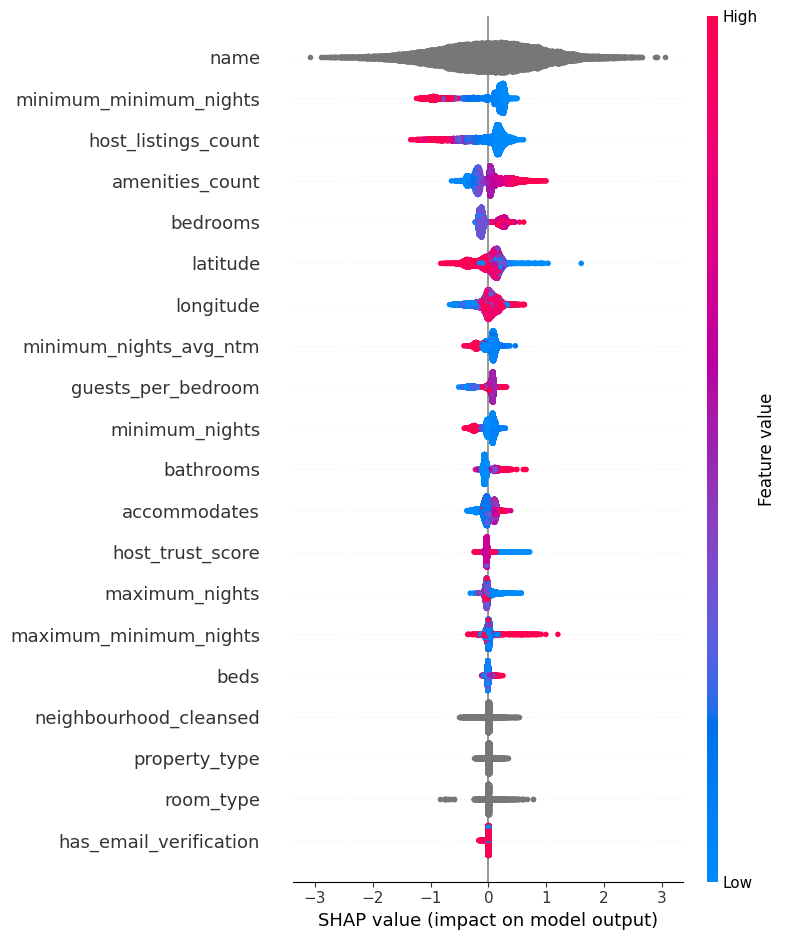

In [56]:
#  Заставляем CatBoost рассчитать SHAP-значения для тестового пула
shap_matrix = best_model.get_feature_importance(test_pool, type="ShapValues")

#  Отделяем SHAP-значения от базового смещения (последний столбец матрицы)
shap_values = shap_matrix[:, :-1]

#  Извлекаем правильные имена признаков из атрибута модели
feature_names = best_model.feature_names_

#  Строим классический summary_plot
shap.summary_plot(
    shap_values,
    X_test[all_features],  # оригинальный датафрейм для цветовой шкалы (синий/красный)
    feature_names=feature_names,
    max_display=20)


**Интерпретация SHAP-анализа:**

Признак name (Текстовое описание) является самым важным признаком для модели с наибольшим разбросом значений SHAP (от -3 до +3). Поскольку он отображен серым цветом (текстовый эмбеддинг), отдельные слова или характеристики в названии могут как радикально увеличивать, так и уменьшать итоговое предсказание.minimum_minimum_nights (минимальный срок бронирования) имеет сильное негативное влияние при высоких значениях. Длинный шлейф розового цвета слева означает, что увеличение минимального количества ночей существенно снижает целевую метрику. host_listings_count - аналогично предыдущему признаку, большое количество объявлений у хоста (красный цвет слева) негативно сказывается на результате, в то время как единичные объявления (синий цвет справа) дают положительный вклад.

amenities_count - четко видно, что большое количество удобств (розовый цвет справа) увеличивает предсказание модели, а малое количество (синий цвет слева) — уменьшает. bedrooms и accommodates - увеличение числа спален и вместимости линейно сдвигает SHAP-значения в положительную сторону.

Географические координаты (latitude и longitude) имеют сложную нелинейную зависимость. Например, для latitude определенные зоны (синий цвет далеко справа) дают сильный положительный импульс.

Признаки созданные на этапе EDA внесли значительный вклад. Общее количество удобств - amenities_count, плотность заселения - guests_per_bedroom и уровень доверия арендодателю - host_trust_score показали свою важность для модели. Но разложения удобств по отдельным категориям - 'amenity_' не оказали значительного влияния на результат. У признаков bedrooms и minimum_nights была самая высокая корреляция с целевой переменной. В модели они сыграли важную роль показав 5-й и 10-й результат.

Для бизнеса важно понимать какие параметры объявления оказывают максимальное влияние на спрос. Например можно сделать выводы, что хосты с большим количеством объявлений мало заботятся о качестве жилья, делая упор на объём.  Объявления нацеленые долгосрочную аренду пользуются меньшей популярностью, чем тем, которые можно бронировать на меньший срок. Количество спален и удобств также повышаю привлекательность жилья. Также и географическое положение является важным. И, главное, текстовой описание жилья может как привлечь клиентов, так и снизить его привлекательность.

## 9. Карточка модели

Оформите карточку финальной версии модели по шаблону ниже.

### Модель v1.0

**Задача:** бинарная классификация — предсказание высокого спроса на объявление.

**Целевая переменная:** `is_high_demand`.

**Алгоритм:** CatBoostClassifier с дополнитеотной обработкой текстовых признаков и гиперпараметрами.

**Гиперпараметры:** learning_rate - 0.0985135661288115, depth - 6, l2_leaf_reg - 1.9585952772525896.

**Признаки:** Категориальные признаки - 'property_type', 'room_type', 'neighbourhood_cleansed'. Числовые признаки - 'host_listings_count',
    'latitude',
    'longitude',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'maximum_nights',
    'minimum_minimum_nights',
    'maximum_minimum_nights',
    'minimum_nights_avg_ntm',
    'amenities_count',
    'host_trust_score',
    'guests_per_bedroom'. Бинарные признаки - 'host_has_profile_pic',
    'host_identity_verified',
    'instant_bookable',
    'has_email_verification',
    'has_work_email_verification',
    'is_shared_bathroom',
    'has_phone_verification'. Текстовые признаки - 'name'. Признаки наличия удобств - 50 признаков начинающихся с "amenity_".

**Метрики на тестовой выборке:**

| Метрика | Значение |
|---------|----------|
| ROC-AUC | 0.8167 |
| F1 |0.2457 |
| Precision |0.6367 |
| Recall |0.1522 |

**Топ-5 важных признаков по SHAP:** name, minimum_minimum_nights, host_listings_count, amenities_count, bedrooms.

**Ограничения модели:** Recall = 0.1522 означает, что модель находит всего ~15% от всех квартир с реальным высоким спросом. Если квартира успешна за счет какого-то одного уникального фактора, которого нет в общей массе, модель ее проигнорирует. 

**Рекомендация к внедрению:** Можно внедрять с дальнейшим усовершенствованием. Модельможет выявлять качественные объявления на основании только характеристик самого жилья, без отзывов и реакций пользователей. Это единственная возможность поднять рейтинг совершенно новых объявлений.

## 10. Итоговые выводы и рекомендации бизнесу

Напишите краткое резюме для бизнеса: что вы обучили, какого результата достигли, что рекомендуете.

**Выводы:**

Обученая модель хорошо работает с текстовыми и категориальными признаки находя нелинейные зависимости с целевой переменной. Значение ROC-AUC (0.8163) говорит о том, что модель отлично ранжирует объекты. Она выдаёт класс «высокий спрос» только тогда, когда у квартиры есть абсолютно все маркеры успеха. Но она плохо находит такие объявления. Модель обучалась на данных в которых отсутвует важный параметр объявления - дата публикации. Из-за этого не отфильтровались объявления не успевшие набрать достаточно истории за последний год и получившие таргет = 0. 

Рекомендации бизнесу:
- Ввести фильтрацию старых "спящих" объявлений под дате последней активности. Это не требует сложных алгоритмов машинного обучения.
- Использовать созданную модель для поднятия рейтинга самых свежих объявлений. Она одобряет только самую безопасную, предсказуемую и очевидную «элиту» среди объявлений.
- Предоставить для дальнейшего усовершенствования модели полные данные с датами публикаций объявлений.
